# Atlas: End-to-End Pipeline Demo
Este notebook executa o pipeline completo utilizando `configs/base.yaml`, gerando os resultados de backtest e walk-forward, comparando com o índice Ibovespa e exibindo KPIs resumidos.

In [1]:
from pathlib import Path
import sys
import logging

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.append(str(PROJECT_ROOT / "src"))

CONFIG_PATH = PROJECT_ROOT / "configs" / "base.yaml"
IBOV_PATH = PROJECT_ROOT / "data" / "benchmark" / "ibovespa_index_b3.csv"

logging.basicConfig(level=logging.WARNING, force=True)
print(f"Projeto: {PROJECT_ROOT}")
print(f"Config: {CONFIG_PATH}")
print(f"Ibovespa CSV: {IBOV_PATH}")

Projeto: D:\GitHub Dic\itau-quant-challenge-2025
Config: D:\GitHub Dic\itau-quant-challenge-2025\configs\base.yaml
Ibovespa CSV: D:\GitHub Dic\itau-quant-challenge-2025\data\benchmark\ibovespa_index_b3.csv


In [2]:
from copy import deepcopy
from dataio.config import load_config
from dataio.loaders import get_panel
import pandas as pd

cfg = load_config(CONFIG_PATH)
start = cfg["dates"]["start"]
end = cfg["dates"]["end"]
panel = get_panel(start, end)
asset_count = panel.index.get_level_values("asset").nunique()
print(f"Painel carregado: {start} -> {end}")
print(f"Observacoes: {panel.shape[0]} | Ativos unicos: {asset_count}")
panel.head()

Painel carregado: 2017-09-04 -> 2025-10-06
Observacoes: 137210 | Ativos unicos: 138


close       volume
date       asset                    
2017-09-04 ABEV3  19.73  241157365.0
           BBAS3  31.84  131657322.0
           BBDC3  32.50   21465083.0
           BBDC4  34.25  144471903.0
           BBSE3  27.93   62636989.0

In [3]:
from backtest.engine import run_backtest
from src.validation.walk_forward import run_walk_forward
from src.validation import run_stat_validations

backtest_cfg = deepcopy(cfg)
backtest_result = run_backtest(backtest_cfg, panel=panel)
backtest_equity = backtest_result["equity_curve"].rename("Backtest")
backtest_kpis = backtest_result["kpis"]

walkforward_cfg = deepcopy(cfg)
walkforward_result = run_walk_forward(walkforward_cfg, panel)
walkforward_equity = walkforward_result["equity_curve"].rename("Walk-forward")
walkforward_kpis = walkforward_result["kpis"]
walkforward_returns = walkforward_result["returns"]

print(f"Backtest dias: {len(backtest_equity)}")
print(f"Walk-forward janelas: {len(walkforward_result['windows'])}")

D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()
D:\GitHub Dic\itau-quant-challenge-2025\src\backtest\engine.py:540: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA va

Backtest dias: 1134
Walk-forward janelas: 9


In [4]:
import pandas as pd

ibov = pd.read_csv(IBOV_PATH, parse_dates=["date"])
ibov = ibov.set_index("date").sort_index()
ibov_series = ibov["close"].rename("Ibovespa")
ibov_series = ibov_series.loc[backtest_equity.index.min():backtest_equity.index.max()].dropna()
ibov_equity = (ibov_series / ibov_series.iloc[0]).rename("Ibovespa")
ibov_equity.head()

date
2020-03-19    1.000000
2020-03-20    0.980937
2020-03-23    0.928649
2020-03-24    1.019627
2020-03-25    1.096984
Name: Ibovespa, dtype: float64

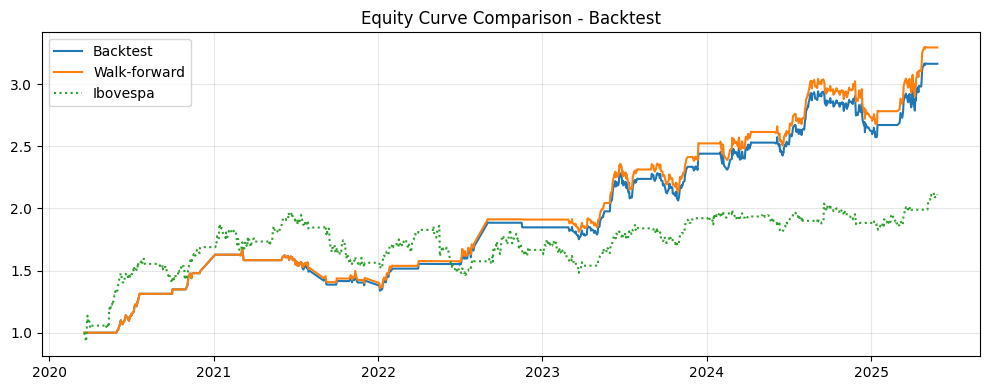

,Backtest,Walk-forward,Ibovespa
Metric,,,
CAGR,0.291656,0.303394,0.211920
Sharpe,1.637371,1.696032,0.911757
Sortino,2.009453,2.069535,1.339298
Vol,0.164707,0.164163,0.243503
MaxDD,-0.202343,-0.190751,-0.254772
AvgTimeUnderWater,24.225000,22.441860,31.655172
MaxTimeUnderWater,270.000000,264.000000,500.000000
Calmar,1.441394,1.590523,0.831801
HitRate,0.541237,0.544041,0.516129


In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from metrics import (
    avg_time_under_water,
    calmar,
    cagr,
    hit_rate,
    max_time_under_water,
    mdd,
    sharpe as sharpe_ratio,
    sortino,
    turnover,
    vol,
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(backtest_equity.index, backtest_equity.values, label='Backtest')
ax.plot(walkforward_equity.index, walkforward_equity.values, label='Walk-forward')
ax.plot(ibov_equity.index, ibov_equity.values, label='Ibovespa', linestyle=':')
ax.set_title('Equity Curve Comparison - Backtest')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

def equity_to_returns(equity):
    return equity.pct_change(fill_method=None).dropna()

wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]

def compute_wf_style_kpis(equity, weights=None):
    returns = equity_to_returns(equity)
    metrics = {
        "CAGR": cagr(equity),
        "Sharpe": sharpe_ratio(returns),
        "Sortino": sortino(returns),
        "Vol": vol(returns),
        "MaxDD": mdd(equity),
        "AvgTimeUnderWater": avg_time_under_water(equity),
        "MaxTimeUnderWater": max_time_under_water(equity),
        "Calmar": calmar(equity),
        "HitRate": hit_rate(returns),
        "Turnover": np.nan,
    }
    if isinstance(weights, pd.DataFrame):
        weight_slice = weights.reindex(returns.index).fillna(0.0)
        turnover_series = turnover(weight_slice).dropna()
        if not turnover_series.empty:
            metrics["Turnover"] = float(turnover_series.mean())
    return metrics

backtest_weights = backtest_result.get("daily_positions")
backtest_metrics = compute_wf_style_kpis(backtest_equity, backtest_weights)
ibov_metrics = compute_wf_style_kpis(ibov_equity, weights=None)
summary_kpis = {
    "Backtest": backtest_metrics,
    "Walk-forward": walkforward_kpis,
    "Ibovespa": ibov_metrics,
}
kpi_df = pd.DataFrame(summary_kpis)
kpi_df = kpi_df.reindex(wf_columns)
kpi_df.index.name = "Metric"
kpi_df

In [6]:
wf_columns = [
    "CAGR", "Sharpe", "Sortino", "Vol", "MaxDD",
    "AvgTimeUnderWater", "MaxTimeUnderWater", "Calmar", "HitRate", "Turnover",
]

wf_rows = []
for idx, window in enumerate(walkforward_result.get("windows", []), start=1):
    window_label = f"WF {idx:02d}"
    kpis = window.get("kpis", {})
    row = {col: kpis.get(col) for col in wf_columns}
    row["Walk-forward"] = window_label
    wf_rows.append(row)

kpi_wf_df = pd.DataFrame(wf_rows)
if not kpi_wf_df.empty:
    kpi_wf_df = kpi_wf_df.set_index("Walk-forward").T
    kpi_wf_df.index.name = "Metric"
    kpi_wf_df.columns = [
        f"WF {idx:02d} {window['oos_start'].date()} -> {window['oos_end'].date()}"
        for idx, window in enumerate(walkforward_result.get("windows", []), start=1)
    ]
kpi_wf_df


,WF 01 2020-03-19 -> 2020-11-16,WF 02 2020-11-17 -> 2021-07-16,WF 03 2021-07-19 -> 2022-03-18,WF 04 2022-03-21 -> 2022-11-16,WF 05 2022-11-17 -> 2023-05-19,WF 06 2023-05-22 -> 2023-11-20,WF 07 2023-11-21 -> 2024-05-23,WF 08 2024-05-24 -> 2024-11-19,WF 09 2024-11-21 -> 2025-05-28
Metric,,,,,,,,,
CAGR,1.185854,0.070322,0.010664,0.546078,0.141997,0.395755,0.173424,0.279264,0.241136
Sharpe,5.016164,0.480256,0.148156,2.304713,1.404525,1.931795,1.163514,1.788453,1.267251
Sortino,7.640754,0.436592,0.122327,3.732899,1.863525,3.047679,1.493844,2.984748,1.540892
Vol,0.158619,0.171488,0.170192,0.197242,0.097958,0.181188,0.146693,0.143527,0.183895
MaxDD,-0.039175,-0.087875,-0.134157,-0.033474,-0.053467,-0.096688,-0.057966,-0.057653,-0.113632
AvgTimeUnderWater,7.100000,39.000000,1.000000,14.750000,28.750000,26.250000,9.625000,6.375000,11.750000
MaxTimeUnderWater,29.000000,39.000000,1.000000,45.000000,75.000000,57.000000,31.000000,19.000000,72.000000
Calmar,30.270662,0.800241,0.079492,16.313496,2.655788,4.093100,2.991815,4.843848,2.122075
HitRate,0.687500,0.534884,0.509434,0.518519,0.517857,0.552083,0.500000,0.537190,0.545455


In [7]:
stat_validation = run_stat_validations(
    walkforward_returns,
    n_trials=max(1, len(walkforward_result.get("windows", []))),
    n_permutations=3000,
    block_size=21,
    random_state=42,
)

import pandas as pd
pd.Series(stat_validation, name="StatValidation")

n_obs                  1134.000000
mean                      0.001105
std                       0.010341
skew                      1.728866
kurt                     22.719075
sharpe                    1.696032
zscore                   15.431225
psr                       1.000000
permutation_pvalue        0.001999
deflated_pvalue           0.017851
deflated_confidence       0.982149
Name: StatValidation, dtype: float64